# 逻辑回归

在本练习中，你将实现逻辑回归，并将其应用于两个不同的数据集。


# 大纲
- [ 1 - 软件包 ](#1)
- [ 2 - 逻辑回归](#2)
  - [ 2.1 问题陈述](#2.1)
  - [ 2.2 加载并可视化数据](#2.2)
  - [ 2.3 Sigmoid 函数](#2.3)
  - [ 2.4 逻辑回归的代价函数](#2.4)
  - [ 2.5 逻辑回归的梯度](#2.5)
  - [ 2.6 使用梯度下降学习参数 ](#2.6)
  - [ 2.7 绘制决策边界](#2.7)
  - [ 2.8 评估逻辑回归](#2.8)
- [ 3 - 正则化逻辑回归](#3)
  - [ 3.1 问题陈述](#3.1)
  - [ 3.2 加载并可视化数据](#3.2)
  - [ 3.3 特征映射](#3.3)
  - [ 3.4 正则化逻辑回归的代价函数](#3.4)
  - [ 3.5 正则化逻辑回归的梯度](#3.5)
  - [ 3.6 使用梯度下降学习参数](#3.6)
  - [ 3.7 绘制决策边界](#3.7)
  - [ 3.8 评估正则化逻辑回归模型](#3.8)

<a name="1"></a>
## 1 - 软件包

首先，运行下面的单元格，导入本作业所需的所有软件包。
- [numpy](www.numpy.org) 是使用 Python 进行科学计算的基础软件包。
- [matplotlib](http://matplotlib.org) 是一个著名的 Python 绘图库。
- ``utils.py`` 包含本作业的辅助函数。你无需修改此文件中的代码。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *
import copy
import math

%matplotlib inline

<a name="2"></a>
## 2 - 逻辑回归

在本练习的这一部分中，你将构建一个逻辑回归模型，用于预测学生能否被大学录取。

<a name="2.1"></a>
### 2.1 问题陈述

假设你是某大学院系的管理人员，希望根据每位申请者两门考试的成绩来确定其被录取的概率。
* 你拥有往届申请者的历史数据，可以将其用作逻辑回归的训练集。
* 对于每个训练样本，你都有申请者两门考试的成绩和录取决定。
* 你的任务是构建一个分类模型，根据申请者两门考试的成绩来估计其被录取的概率。

<a name="2.2"></a>
### 2.2 加载数据并进行可视化

首先，加载本任务所需的数据集。
- 下面所示的 `load_dataset()` 函数将数据加载到变量 `X_train` 和 `y_train` 中
  - `X_train` 包含某位学生两门考试的成绩
  - `y_train` 是录取决定
      - 如果学生被录取，则为 `y_train = 1`
      - 如果学生未被录取，则为 `y_train = 0`
  - `X_train` 和 `y_train` 都是 NumPy 数组。

In [2]:
# load dataset
X_train, y_train = load_data("data/ex2data1.txt")

#### 查看变量
让我们进一步熟悉你的数据集。
- 一个很好的起点是直接打印每个变量，看看其中包含什么。

下面的代码打印 `X_train` 的前五个值以及该变量的类型。

In [3]:
print("First five elements in X_train are:\n", X_train[:5])
print("Type of X_train:",type(X_train))

First five elements in X_train are:
 [[34.62365962 78.02469282]
 [30.28671077 43.89499752]
 [35.84740877 72.90219803]
 [60.18259939 86.3085521 ]
 [79.03273605 75.34437644]]
Type of X_train: <class 'numpy.ndarray'>


现在打印 `y_train` 的前五个值

In [4]:
print("First five elements in y_train are:\n", y_train[:5])
print("Type of y_train:",type(y_train))

First five elements in y_train are:
 [0. 0. 0. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


#### 检查变量的维度

查看数据维度也是熟悉数据的一种实用方法。让我们打印 `X_train` 和 `y_train` 的形状，看看数据集中有多少个训练样本。

In [5]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (100, 2)
The shape of y_train is: (100,)
We have m = 100 training examples


#### 可视化数据

在开始实现任何学习算法之前，只要条件允许，先将数据可视化总是很有帮助。
- 以下代码在二维图中显示数据（如下所示），坐标轴分别代表两门考试的成绩，并使用不同的标记显示正样本和负样本。
- 我们使用 ``utils.py`` 文件中的辅助函数生成该图。

<img src="images/figure 1.png" width="450" height="450">


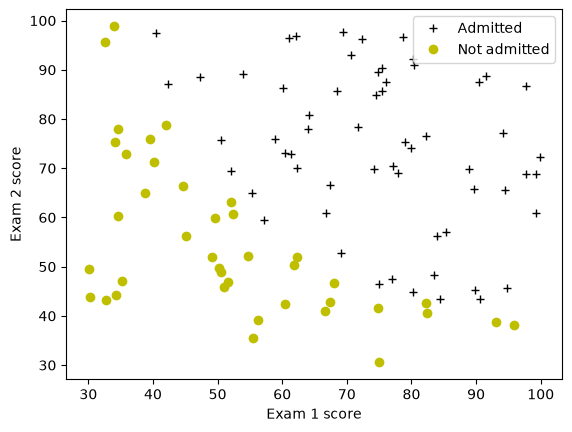

In [6]:
# Plot examples
plot_data(X_train, y_train[:], pos_label="Admitted", neg_label="Not admitted")

# Set the y-axis label
plt.ylabel('Exam 2 score') 
# Set the x-axis label
plt.xlabel('Exam 1 score') 
plt.legend(loc="upper right")
plt.show()

你的目标是构建一个逻辑回归模型来拟合这些数据。
- 借助该模型，可以根据一名新学生两门考试的成绩预测其是否会被录取。

<a name="2.3"></a>
### 2.3 Sigmoid 函数

回想一下，对于逻辑回归，模型表示为

$$ f_{\mathbf{w},b}(x) = g(\mathbf{w}\cdot \mathbf{x} + b)$$
其中函数 $g$ 是 sigmoid 函数。sigmoid 函数定义为：

$$g(z) = \frac{1}{1+e^{-z}}$$

首先实现 sigmoid 函数，以便本作业的其余部分使用。

<a name='ex-01'></a>
### 练习 1
请完成 `sigmoid` 函数以计算

$$g(z) = \frac{1}{1+e^{-z}}$$

请注意：
- `z` 并不总是单个数，也可以是数值数组。
- 如果输入是数值数组，我们希望对输入数组中的每个值应用 sigmoid 函数。

如果遇到困难，可以查看下面单元格之后给出的提示来帮助完成实现。

In [7]:
# UNQ_C1
# GRADED FUNCTION: sigmoid

def sigmoid(z):
    """
    Compute the sigmoid of z

    Args:
        z (ndarray): A scalar, numpy array of any size.

    Returns:
        g (ndarray): sigmoid(z), with the same shape as z
         
    """
          
    ### START CODE HERE ### 
    g = 1 / (1 + np.exp(-z))
    ### END SOLUTION ###  
    
    return g

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
       
`numpy` 有一个名为 [`np.exp()`](https://numpy.org/doc/stable/reference/generated/numpy.exp.html) 的函数，它提供了一种便捷方式，用于计算输入数组（`z`）中所有元素的指数（$e^{z}$）。

<details>
          <summary><font size="2" color="darkblue"><b> 点击查看更多提示</b></font></summary>
        
  - 可以将 $e^{-z}$ 转换为代码 `np.exp(-z)`
    
  - 可以将 $1/e^{-z}$ 转换为代码 `1/np.exp(-z)`
    
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `g`
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 g 的提示</b></font></summary>
        <code>g = 1 / (1 + np.exp(-z))</code>
    </details>


</details>

完成后，尝试在下面的单元格中调用 `sigmoid(x)` 来测试几个值。
- 对于较大的正 x 值，sigmoid 应接近 1；对于较大的负值，sigmoid 应接近 0。
- 计算 `sigmoid(0)` 应恰好得到 0.5。

In [9]:
print ("sigmoid(0) = " + str(sigmoid(0)))

sigmoid(0) = 0.5


**预期输出**：
<table>
  <tr>
    <td> <b>sigmoid(0)<b></td>
    <td> 0.5 </td>
  </tr>
</table>
    
- 如前所述，代码还应适用于向量和矩阵。对于矩阵，函数应对每个元素执行 sigmoid 函数。

In [10]:
print ("sigmoid([ -1, 0, 1, 2]) = " + str(sigmoid(np.array([-1, 0, 1, 2]))))

# UNIT TESTS
from public_tests import *
sigmoid_test(sigmoid)

sigmoid([ -1, 0, 1, 2]) = [0.26894142 0.5        0.73105858 0.88079708]
All tests passed!


**预期输出**：
<table>
  <tr>
    <td><b>sigmoid([-1, 0, 1, 2])<b></td> 
    <td>[0.26894142        0.5           0.73105858        0.88079708]</td> 
  </tr>    
  
</table>

<a name="2.4"></a>
### 2.4 逻辑回归的代价函数

在本节中，你将实现逻辑回归的代价函数。

<a name='ex-02'></a>
### 练习 2

请使用以下方程完成 `compute_cost` 函数。

回顾一下，对于逻辑回归，代价函数的形式为

$$ J(\mathbf{w},b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) \right] \tag{1}$$

其中：
* m 是数据集中的训练样本数


* $loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)})$ 是单个数据点的代价，即：

    $$loss(f_{\mathbf{w},b}(\mathbf{x}^{(i)}), y^{(i)}) = (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \tag{2}$$
    
    
* $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ 是模型的预测，而 $y^{(i)}$ 是真实标签

* $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(\mathbf{w} \cdot \mathbf{x^{(i)}} + b)$，其中函数 $g$ 是 sigmoid 函数。
    * 在计算 $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$ 之前，先计算中间变量 $z_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x^{(i)}} + b = w_0x^{(i)}_0 + ... + w_{n-1}x^{(i)}_{n-1} + b$ 可能会有帮助，其中 $n$ 是特征数

注意：
* 在执行此操作时，请记住变量 `X_train` 和 `y_train` 不是标量值，而是形状分别为（$m, n$）和（$𝑚$,1）的矩阵，其中 $𝑛$ 是特征数，$𝑚$ 是训练样本数。
* 这一部分可以使用你在上面实现的 sigmoid 函数。

如果遇到困难，可以查看下方单元格之后给出的提示，以帮助你完成实现。

In [11]:
# UNQ_C2
# GRADED FUNCTION: compute_cost
def compute_cost(X, y, w, b, lambda_= 1):
    """
    Computes the cost over all examples
    Args:
      X : (ndarray Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : scalar Values of bias parameter of the model
      lambda_: unused placeholder
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    ### START CODE HERE ###
    loss_sum = 0
    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb_ij = w[j] * X[i][j]
            z_wb += z_wb_ij
        z_wb += b
        f_wb = sigmoid(z_wb)
        loss = -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)
        loss_sum += loss
    total_cost = (1 /m) * loss_sum
            
    ### END CODE HERE ### 

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
   * 可以在代码中按如下方式表示求和运算符，例如 $h = \sum\limits_{i = 0}^{m-1} 2i$：
    ```python 
        h = 0
        for i in range(m):
            h = h + 2*i
    ```
  
   * 在本例中，可以使用 for 循环遍历 `X` 中的所有样本，并将每次迭代得到的 `loss` 累加到循环外初始化的变量（`loss_sum`）中。

   * 然后，可以返回 `total_cost`，即用 `loss_sum` 除以 `m`。
     
    <details>
          <summary><font size="2" color="darkblue"><b> 点击查看更多提示</b></font></summary>
        
    * 此函数的整体实现可以采用以下结构
    ```python 
    def compute_cost(X, y, w, b, lambda_= 1):
        m, n = X.shape
    
        ### START CODE HERE ###
        loss_sum = 0 
        
        # Loop over each training example
        for i in range(m): 
            
            # First calculate z_wb = w[0]*X[i][0]+...+w[n-1]*X[i][n-1]+b
            z_wb = 0 
            # Loop over each feature
            for j in range(n): 
                # Add the corresponding term to z_wb
                z_wb_ij = # Your code here to calculate w[j] * X[i][j]
                z_wb += z_wb_ij # equivalent to z_wb = z_wb + z_wb_ij
            # Add the bias term to z_wb
            z_wb += b # equivalent to z_wb = z_wb + b
        
            f_wb = # Your code here to calculate prediction f_wb for a training example
            loss =  # Your code here to calculate loss for a training example
            
            loss_sum += loss # equivalent to loss_sum = loss_sum + loss
        
        total_cost = (1 / m) * loss_sum  
        ### END CODE HERE ### 
        
        return total_cost
    ```
    
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `z_wb_ij`、`f_wb` 和 `cost`。
    <details>
          <summary><font size="2" color="darkblue"><b>计算 z_wb_ij 的提示</b></font></summary>
           &emsp; &emsp; <code>z_wb_ij = w[j]*X[i][j] </code>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
           &emsp; &emsp; $f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = g(z_{\mathbf{w},b}(\mathbf{x}^{(i)}))$，其中 $g$ 是 sigmoid 函数。只需调用上面实现的 `sigmoid` 函数即可。
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f 的更多提示</b></font></summary>
               &emsp; &emsp; 可以按如下方式计算 f_wb：<code>f_wb = sigmoid(z_wb) </code>
           </details>
    </details>

     <details>
          <summary><font size="2" color="darkblue"><b>计算损失的提示</b></font></summary>
          &emsp; &emsp; 可以使用 <a href="https://numpy.org/doc/stable/reference/generated/numpy.log.html">np.log</a> 函数计算对数
          <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算损失的更多提示</b></font></summary>
              &emsp; &emsp; 可以按如下方式计算损失：<code>loss =  -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)</code>
          </details>
    </details>
        
    </details>

</details>

运行下面的单元格，使用参数 $w$ 的两种不同初始化来检查 `compute_cost` 函数的实现

In [12]:
m, n = X_train.shape

# Compute and display cost with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.
cost = compute_cost(X_train, y_train, initial_w, initial_b)
print('Cost at initial w (zeros): {:.3f}'.format(cost))

Cost at initial w (zeros): 0.693


**预期输出**：
<table>
  <tr>
    <td> <b>初始 w（全零）处的代价<b></td>
    <td> 0.693 </td> 
  </tr>
</table>

In [13]:
# Compute and display cost with non-zero w
test_w = np.array([0.2, 0.2])
test_b = -24.
cost = compute_cost(X_train, y_train, test_w, test_b)

print('Cost at test w,b: {:.3f}'.format(cost))


# UNIT TESTS
compute_cost_test(compute_cost)


Cost at test w,b: 0.218
All tests passed!


**预期输出**：
<table>
  <tr>
    <td> <b>测试 w、b 处的代价<b></td>
    <td> 0.218 </td> 
  </tr>
</table>

<a name="2.5"></a>
### 2.5 逻辑回归的梯度

在本节中，你将实现逻辑回归的梯度。

回想一下，梯度下降算法为：

$$\begin{align*}& \text{repeat until convergence:} \; \lbrace \newline \; & b := b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b} \newline       \; & w_j := w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{1}  \; & \text{for j := 0..n-1}\newline & \rbrace\end{align*}$$

其中参数 $b$、$w_j$ 同时更新


<a name='ex-03'></a>
### 练习 3

请完成 `compute_gradient` 函数，按照下面的公式 (2) 和 (3) 计算 $\frac{\partial J(\mathbf{w},b)}{\partial w}$、$\frac{\partial J(\mathbf{w},b)}{\partial b}$。

$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$
* m 是数据集中的训练样本数量；

    
* $f_{\mathbf{w},b}(x^{(i)})$ 是模型的预测值，$y^{(i)}$ 是实际标签。


- **注意**：虽然这个梯度看起来与线性回归梯度相同，但公式实际上不同，因为线性回归和逻辑回归对 $f_{\mathbf{w},b}(x)$ 的定义不同。

与之前一样，您可以使用上面实现的 sigmoid 函数。如果遇到困难，可以查看下面单元格之后提供的提示来帮助完成实现。

In [26]:
# UNQ_C3
# GRADED FUNCTION: compute_gradient
def compute_gradient(X, y, w, b, lambda_=None): 
    """
    Computes the gradient for logistic regression 
 
    Args:
      X : (ndarray Shape (m,n)) variable such as house size 
      y : (array_like Shape (m,1)) actual value 
      w : (array_like Shape (n,1)) values of parameters of the model      
      b : (scalar)                 value of parameter of the model 
      lambda_: unused placeholder.
    Returns
      dj_dw: (array_like Shape (n,1)) The gradient of the cost w.r.t. the parameters w. 
      dj_db: (scalar)                The gradient of the cost w.r.t. the parameter b. 
    """
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.

    ### START CODE HERE ### 
    err  = 0.
    for i in range(m):
        z_wb = 0
        for j in range(n):
            z_wb_ij = X[i, j] * w[j]
            z_wb += z_wb_ij
        z_wb += b
        f_wb = sigmoid(z_wb)
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        for j in range(n):
            dj_dw_ij = (f_wb - y[i]) * X[i][j]
            dj_dw[j] += dj_dw_ij
            
    dj_dw = dj_dw / m
    dj_db = dj_db / m
    ### END CODE HERE ###

        
    return dj_db, dj_dw

 <details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
* 下面展示了该函数整体实现的组织方式。
    ```python 
       def compute_gradient(X, y, w, b, lambda_=None): 
            m, n = X.shape
            dj_dw = np.zeros(w.shape)
            dj_db = 0.
        
            ### START CODE HERE ### 
            err  = 0.
            for i in range(m):
                # Calculate f_wb (exactly as you did in the compute_cost function above)
                f_wb = 
        
                # Calculate the  gradient for b from this example
                dj_db_i = # Your code here to calculate the error
        
                # add that to dj_db
                dj_db += dj_db_i
        
                # get dj_dw for each attribute
                for j in range(n):
                    # You code here to calculate the gradient from the i-th example for j-th attribute
                    dj_dw_ij =  
                    dj_dw[j] += dj_dw_ij
        
            # divide dj_db and dj_dw by total number of examples
            dj_dw = dj_dw / m
            dj_db = dj_db / m
            ### END CODE HERE ###
       
            return dj_db, dj_dw
    ```
  
    如果您仍然没有思路，可以查看下面给出的提示，了解如何计算 `f_wb`、`dj_db_i` 和 `dj_dw_ij`。
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
           &emsp; &emsp; 回顾一下，您已经在上面的 <code>compute_cost</code> 中计算过 f_wb——有关每个中间项的详细计算提示，请查看该练习下方的提示部分。
           <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f_wb 的更多提示</b></font></summary>
              &emsp; &emsp; 您可以按如下方式计算 f_wb：
               <pre>
               for i in range(m):   
                   # Calculate f_wb (exactly how you did it in the compute_cost function above)
                   z_wb = 0
                   # Loop over each feature
                   for j in range(n): 
                       # Add the corresponding term to z_wb
                       z_wb_ij = X[i, j] * w[j]
                       z_wb += z_wb_ij
            
                   # Add bias term 
                   z_wb += b
        
                   # Calculate the prediction from the model
                   f_wb = sigmoid(z_wb)
    </details>
        
    </details>
    <details>
          <summary><font size="2" color="darkblue"><b>计算 dj_db_i 的提示</b></font></summary>
           &emsp; &emsp; 您可以按如下方式计算 dj_db_i：<code>dj_db_i = f_wb - y[i]</code>
    </details>
        
    <details>
          <summary><font size="2" color="darkblue"><b>计算 dj_dw_ij 的提示</b></font></summary>
        &emsp; &emsp; 您可以按如下方式计算 dj_dw_ij：<code>dj_dw_ij = (f_wb - y[i])* X[i][j]</code>
    </details>

</details>

运行下面的单元格，使用参数 $w$ 的两种不同初始化来检查 `compute_gradient` 函数的实现

In [27]:
# Compute and display gradient with w initialized to zeroes
initial_w = np.zeros(n)
initial_b = 0.

dj_db, dj_dw = compute_gradient(X_train, y_train, initial_w, initial_b)
print(f'dj_db at initial w (zeros):{dj_db}' )
print(f'dj_dw at initial w (zeros):{dj_dw.tolist()}' )

dj_db at initial w (zeros):-0.1
dj_dw at initial w (zeros):[-12.00921658929115, -11.262842205513591]


**预期输出**：
<table>
  <tr>
    <td> <b>初始 w（全零）处的 dj_db<b></td>
    <td> -0.1 </td> 
  </tr>
  <tr>
    <td> <b>初始 w（全零）处的 ddj_dw：<b></td>
    <td> [-12.00921658929115, -11.262842205513591] </td> 
  </tr>
</table>

In [28]:
# Compute and display cost and gradient with non-zero w
test_w = np.array([ 0.2, -0.5])
test_b = -24
dj_db, dj_dw  = compute_gradient(X_train, y_train, test_w, test_b)

print('dj_db at test_w:', dj_db)
print('dj_dw at test_w:', dj_dw.tolist())

# UNIT TESTS    
compute_gradient_test(compute_gradient)


dj_db at test_w: -0.5999999999991071
dj_dw at test_w: [-44.831353617873795, -44.37384124953978]
All tests passed!


**预期输出**：
<table>
  <tr>
    <td> <b>初始 w（全零）处的 dj_db<b></td>
    <td> -0.5999999999991071 </td>
  </tr>
  <tr>
    <td> <b>初始 w（全零）处的 ddj_dw：<b></td>
    <td>  [-44.8313536178737957, -44.37384124953978] </td>
  </tr>
</table>

<a name="2.6"></a>
### 2.6 使用梯度下降学习参数

与上一次作业类似，现在您将使用梯度下降寻找逻辑回归模型的最优参数。
- 这一部分无需实现任何内容，只需运行下面的单元格。

- 验证梯度下降是否正常工作的一种好方法，是观察 $J(\mathbf{w},b)$ 的值，并确认它在每一步都在减小。

- 假设梯度实现和代价计算都正确，$J(\mathbf{w},b)$ 的值就不应增加，并应在算法结束时收敛到一个稳定值。

In [29]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_): 
    """
    Performs batch gradient descent to learn theta. Updates theta by taking 
    num_iters gradient steps with learning rate alpha
    
    Args:
      X :    (array_like Shape (m, n)
      y :    (array_like Shape (m,))
      w_in : (array_like Shape (n,))  Initial values of parameters of the model
      b_in : (scalar)                 Initial value of parameter of the model
      cost_function:                  function to compute cost
      alpha : (float)                 Learning rate
      num_iters : (int)               number of iterations to run gradient descent
      lambda_ (scalar, float)         regularization constant
      
    Returns:
      w : (array_like Shape (n,)) Updated values of parameters of the model after
          running gradient descent
      b : (scalar)                Updated value of parameter of the model after
          running gradient descent
    """
    
    # number of training examples
    m = len(X)
    
    # An array to store cost J and w's at each iteration primarily for graphing later
    J_history = []
    w_history = []
    
    for i in range(num_iters):

        # Calculate the gradient and update the parameters
        dj_db, dj_dw = gradient_function(X, y, w_in, b_in, lambda_)   

        # Update Parameters using w, b, alpha and gradient
        w_in = w_in - alpha * dj_dw               
        b_in = b_in - alpha * dj_db              
       
        # Save cost J at each iteration
        if i<100000:      # prevent resource exhaustion 
            cost =  cost_function(X, y, w_in, b_in, lambda_)
            J_history.append(cost)

        # Print cost every at intervals 10 times or as many iterations if < 10
        if i% math.ceil(num_iters/10) == 0 or i == (num_iters-1):
            w_history.append(w_in)
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}   ")
        
    return w_in, b_in, J_history, w_history #return w and J,w history for graphing

现在，让我们运行上面的梯度下降算法，为数据集学习参数。

**注意**

下面的代码块需要几分钟才能运行完，非向量化版本尤其如此。您可以减小 `iterations` 来测试实现并更快迭代。如果时间充裕，可尝试运行 100,000 次迭代以获得更好的结果。

In [30]:
np.random.seed(1)
intial_w = 0.01 * (np.random.rand(2).reshape(-1,1) - 0.5)
initial_b = -8


# Some gradient descent settings
iterations = 10000
alpha = 0.001

w,b, J_history,_ = gradient_descent(X_train ,y_train, initial_w, initial_b, 
                                   compute_cost, compute_gradient, alpha, iterations, 0)

Iteration    0: Cost     1.01   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   


<details>
<summary>
    <b>预期输出：代价     0.30，（单击查看详情）：</b>
</summary>

    # 使用以下设置
    np.random.seed(1)
    intial_w = 0.01 * (np.random.rand(2).reshape(-1,1) - 0.5)
    initial_b = -8
    iterations = 10000
    alpha = 0.001
    #

```
Iteration    0: Cost     1.01   
Iteration 1000: Cost     0.31   
Iteration 2000: Cost     0.30   
Iteration 3000: Cost     0.30   
Iteration 4000: Cost     0.30   
Iteration 5000: Cost     0.30   
Iteration 6000: Cost     0.30   
Iteration 7000: Cost     0.30   
Iteration 8000: Cost     0.30   
Iteration 9000: Cost     0.30   
Iteration 9999: Cost     0.30   
```

<a name="2.7"></a>
### 2.7 绘制决策边界

现在使用梯度下降得到的最终参数来绘制线性拟合。如果正确实现了前面的部分，应看到下图：  
<img src="images/figure 2.png"  width="450" height="450">

我们将使用 `utils.py` 文件中的辅助函数创建此图。

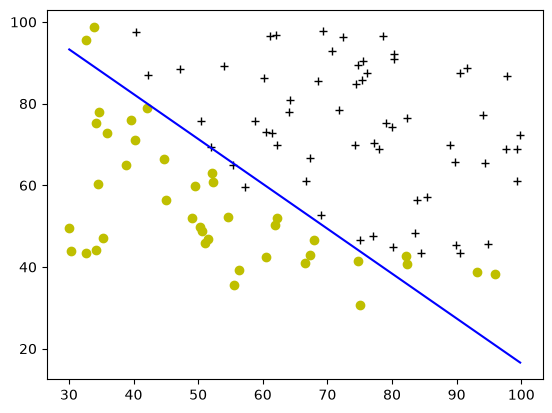

In [31]:
plot_decision_boundary(w, b, X_train, y_train)

<a name="2.8"></a>
### 2.8 评估逻辑回归

可以通过查看所学模型在训练集上的预测效果，评估所找到参数的质量。

你将在下面实现 `predict` 函数来完成这一任务。

<a name='ex-04'></a>
### 练习 4

请完成 `predict` 函数，以便在给定数据集以及学习得到的参数向量 $w$ 和 $b$ 时，生成 `1` 或 `0` 预测。
- 首先，你需要为每个样本计算模型 $f(x^{(i)}) = g(w \cdot x^{(i)})$ 的预测
    - 你之前已经在上面的部分实现过这一点
- 我们将模型的输出（$f(x^{(i)})$）解释为：在给定 $x^{(i)}$ 且由 $w$ 参数化时，$y^{(i)}=1$ 的概率。
- 因此，要从逻辑回归模型获得最终预测（$y^{(i)}=0$ 或 $y^{(i)}=1$），可以使用以下启发式规则：

  如果 $f(x^{(i)}) >= 0.5$，则预测 $y^{(i)}=1$
  
  如果 $f(x^{(i)}) < 0.5$，则预测 $y^{(i)}=0$
    
如果遇到困难，可以查看下方单元格之后给出的提示，以帮助你完成实现。

In [32]:
# UNQ_C4
# GRADED FUNCTION: predict

def predict(X, w, b): 
    """
    Predict whether the label is 0 or 1 using learned logistic
    regression parameters w
    
    Args:
    X : (ndarray Shape (m, n))
    w : (array_like Shape (n,))      Parameters of the model
    b : (scalar, float)              Parameter of the model

    Returns:
    p: (ndarray (m,1))
        The predictions for X using a threshold at 0.5
    """
    # number of training examples
    m, n = X.shape   
    p = np.zeros(m)
   
    ### START CODE HERE ### 
    # Loop over each example
    for i in range(m):   
        z_wb = 0
        # Loop over each feature
        for j in range(n): 
            # Add the corresponding term to z_wb
            z_wb_ij = X[i, j] * w[j]
            z_wb += z_wb_ij
        
        # Add bias term 
        z_wb += b 
        # Calculate the prediction for this example
        f_wb = sigmoid(z_wb)

        # Apply the threshold
        p[i] = f_wb >= 0.5
        
    ### END CODE HERE ### 
    return p

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
* 此函数的整体实现可以采用以下结构
    ```python 
       def predict(X, w, b): 
            # number of training examples
            m, n = X.shape   
            p = np.zeros(m)
   
            ### START CODE HERE ### 
            # Loop over each example
            for i in range(m):   
                
                # Calculate f_wb (exactly how you did it in the compute_cost function above) 
                # using a couple of lines of code
                f_wb = 

                # Calculate the prediction for that training example 
                p[i] = # Your code here to calculate the prediction based on f_wb
        
            ### END CODE HERE ### 
            return p
    ```
  
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `f_wb` 和 `p[i]`
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 f_wb 的提示</b></font></summary>
           &emsp; &emsp; 回想一下，你已经在上面的 <code>compute_cost</code> 中计算了 f_wb——关于如何计算各个中间项的详细提示，请查看该练习下方的提示部分
           <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 f_wb 的更多提示</b></font></summary>
              &emsp; &emsp; 可以按如下方式计算 f_wb
               <pre>
               for i in range(m):   
                   # Calculate f_wb (exactly how you did it in the compute_cost function above)
                   z_wb = 0
                   # Loop over each feature
                   for j in range(n): 
                       # Add the corresponding term to z_wb
                       z_wb_ij = X[i, j] * w[j]
                       z_wb += z_wb_ij
            
                   # Add bias term 
                   z_wb += b
        
                   # Calculate the prediction from the model
                   f_wb = sigmoid(z_wb)
    </details>
        
    </details>
    <details>
          <summary><font size="2" color="darkblue"><b>计算 p[i] 的提示</b></font></summary>
           &emsp; &emsp; 例如，如果希望在 y 小于 3 时令 x = 1，否则令 x = 0，可以在代码中写成 <code>x = y < 3 </code>。现在用同样的方法，使 f_wb >= 0.5 时 p[i] = 1，否则 p[i] = 0。
           <details>
              <summary><font size="2" color="blue"><b>&emsp; &emsp; 计算 p[i] 的更多提示</b></font></summary>
              &emsp; &emsp; 可以按如下方式计算 p[i]：<code>p[i] = f_wb >= 0.5</code>
          </details>
    </details>

</details>

完成函数 `predict` 后，让我们运行下面的代码，通过计算分类器正确分类的样本百分比来报告训练准确率。

In [33]:
# Test your predict code
np.random.seed(1)
tmp_w = np.random.randn(2)
tmp_b = 0.3    
tmp_X = np.random.randn(4, 2) - 0.5

tmp_p = predict(tmp_X, tmp_w, tmp_b)
print(f'Output of predict: shape {tmp_p.shape}, value {tmp_p}')

# UNIT TESTS        
predict_test(predict)

Output of predict: shape (4,), value [0. 1. 1. 1.]
All tests passed!


**预期输出** 

<table>
  <tr>
    <td> <b>predict 的输出：shape (4,),value [0. 1. 1. 1.]<b></td>
  </tr>
</table>

现在，让我们用它计算训练集上的准确率

In [34]:
#Compute accuracy on our training set
p = predict(X_train, w,b)
print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 92.000000


<table>
  <tr>
    <td> <b>训练准确率（约）：<b></td>
    <td> 92.00 </td> 
  </tr>
</table>

<a name="3"></a>
## 3 - 正则化逻辑回归

在本练习的这一部分中，你将实现正则化逻辑回归，用于预测制造厂生产的微芯片能否通过质量保证（QA）。在 QA 期间，每枚微芯片都要经过多项测试，以确保其正常工作。

<a name="3.1"></a>
### 3.1 问题陈述

假设你是工厂的产品经理，手中有一些微芯片在两项不同测试中的结果。
- 你希望根据这两项测试判断微芯片应该被接受还是拒绝。
- 为帮助你做出决定，你有一个以往微芯片测试结果的数据集，可据此构建逻辑回归模型。

<a name="3.2"></a>
### 3.2 加载数据并进行可视化

与本练习前面的部分相似，首先加载本任务的数据集并进行可视化。

- 下面所示的 `load_dataset()` 函数将数据加载到变量 `X_train` 和 `y_train` 中
  - `X_train` 包含微芯片的两项测试结果
  - `y_train` 包含 QA 结果
      - 如果微芯片被接受，则为 `y_train = 1`
      - 如果微芯片被拒绝，则为 `y_train = 0`
  - `X_train` 和 `y_train` 都是 NumPy 数组。

In [35]:
# load dataset
X_train, y_train = load_data("data/ex2data2.txt")

#### 查看变量

下面的代码会打印 `X_train` 和 `y_train` 的前五个值，以及这些变量的类型。

In [36]:
# print X_train
print("X_train:", X_train[:5])
print("Type of X_train:",type(X_train))

# print y_train
print("y_train:", y_train[:5])
print("Type of y_train:",type(y_train))

X_train: [[ 0.051267  0.69956 ]
 [-0.092742  0.68494 ]
 [-0.21371   0.69225 ]
 [-0.375     0.50219 ]
 [-0.51325   0.46564 ]]
Type of X_train: <class 'numpy.ndarray'>
y_train: [1. 1. 1. 1. 1.]
Type of y_train: <class 'numpy.ndarray'>


#### 检查变量的维度

查看数据维度也是熟悉数据的一种实用方法。让我们打印 `X_train` 和 `y_train` 的形状，看看数据集中有多少个训练样本。

In [37]:
print ('The shape of X_train is: ' + str(X_train.shape))
print ('The shape of y_train is: ' + str(y_train.shape))
print ('We have m = %d training examples' % (len(y_train)))

The shape of X_train is: (118, 2)
The shape of y_train is: (118,)
We have m = 118 training examples


#### 数据可视化

辅助函数 `plot_data`（来自 `utils.py`）用于生成类似图 3 的图形，其中两个坐标轴表示两项测试分数，并用不同的标记显示正例（y = 1，录取）和负例（y = 0，拒绝）。

<img src="images/figure 3.png"  width="450" height="450">

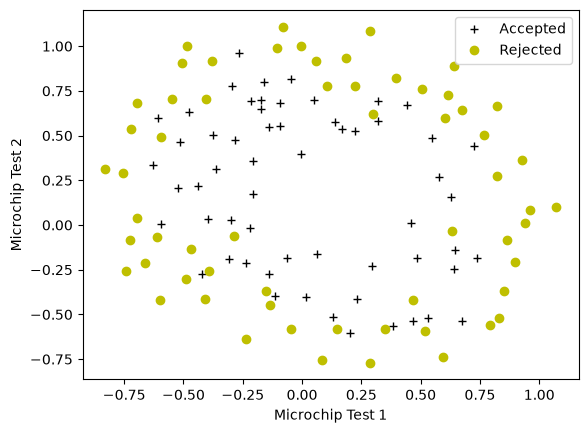

In [38]:
# Plot examples
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")

# Set the y-axis label
plt.ylabel('Microchip Test 2') 
# Set the x-axis label
plt.xlabel('Microchip Test 1') 
plt.legend(loc="upper right")
plt.show()

图 3 表明，无法在图中用一条直线将数据集分为正例和负例。因此，直接对该数据集应用逻辑回归不会取得良好效果，因为逻辑回归只能找到线性决策边界。

<a name="3.3"></a>
### 3.3 特征映射

更好地拟合数据的一种方法，是从每个数据点创建更多特征。在给定的函数 `map_feature` 中，我们会将特征映射为由 $x_1$ 和 $x_2$ 构成的、最高到六次方的所有多项式项。

$$\mathrm{map\_feature}(x) = 
\left[\begin{array}{c}
x_1\\
x_2\\
x_1^2\\
x_1 x_2\\
x_2^2\\
x_1^3\\
\vdots\\
x_1 x_2^5\\
x_2^6\end{array}\right]$$

经过这种映射，原先包含两个特征（两次 QA 测试的分数）的向量被转换为一个 27 维向量。

- 在这个更高维特征向量上训练的逻辑回归分类器将具有更复杂的决策边界，并且在二维图中绘制时将是非线性的。
- 我们已经在 utils.py 中为你提供了 `map_feature` 函数。

In [42]:
print("Original shape of data:", X_train.shape)

mapped_X =  map_feature(X_train[:, 0], X_train[:, 1])
print("Shape after feature mapping:", mapped_X.shape)

Original shape of data: (118, 2)
Shape after feature mapping: (118, 27)


我们还打印 `X_train` 和 `mapped_X` 的前几个元素，查看这种变换。

In [43]:
print("X_train[0]:", X_train[0])
print("mapped X_train[0]:", mapped_X[0])

X_train[0]: [0.051267 0.69956 ]
mapped X_train[0]: [5.12670000e-02 6.99560000e-01 2.62830529e-03 3.58643425e-02
 4.89384194e-01 1.34745327e-04 1.83865725e-03 2.50892595e-02
 3.42353606e-01 6.90798869e-06 9.42624411e-05 1.28625106e-03
 1.75514423e-02 2.39496889e-01 3.54151856e-07 4.83255257e-06
 6.59422333e-05 8.99809795e-04 1.22782870e-02 1.67542444e-01
 1.81563032e-08 2.47750473e-07 3.38066048e-06 4.61305487e-05
 6.29470940e-04 8.58939846e-03 1.17205992e-01]


虽然特征映射使我们能够构建表达能力更强的分类器，但也使其更容易过拟合。在练习接下来的部分中，你将实现正则化逻辑回归来拟合数据，并亲自观察正则化如何帮助缓解过拟合问题。

<a name="3.4"></a>
### 3.4 正则化逻辑回归的代价函数

在这一部分，你将实现正则化逻辑回归的代价函数。

回想一下，对于正则化逻辑回归，代价函数的形式为
$$J(\mathbf{w},b) = \frac{1}{m}  \sum_{i=0}^{m-1} \left[ -y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) \right] + \frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

将其与不含正则化的代价函数（你已在上面实现）进行比较，后者形式为

$$ J(\mathbf{w}.b) = \frac{1}{m}\sum_{i=0}^{m-1} \left[ (-y^{(i)} \log\left(f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right) - \left( 1 - y^{(i)}\right) \log \left( 1 - f_{\mathbf{w},b}\left( \mathbf{x}^{(i)} \right) \right)\right]$$

二者的区别是正则化项，即 $$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$
请注意，参数 $b$ 不进行正则化。

<a name='ex-05'></a>
### 练习 5

请完成下面的 `compute_cost_reg` 函数，为 $w$ 中的每个元素计算以下项：
$$\frac{\lambda}{2m}  \sum_{j=0}^{n-1} w_j^2$$

随后，起始代码会将其加到不带正则化的代价（即上面 `compute_cost` 中计算的代价）上，计算带正则化的代价。

如果遇到困难，可以查看下方单元格之后给出的提示，以帮助你完成实现。

In [44]:
# UNQ_C5
def compute_cost_reg(X, y, w, b, lambda_ = 1):
    """
    Computes the cost over all examples
    Args:
      X : (array_like Shape (m,n)) data, m examples by n features
      y : (array_like Shape (m,)) target value 
      w : (array_like Shape (n,)) Values of parameters of the model      
      b : (array_like Shape (n,)) Values of bias parameter of the model
      lambda_ : (scalar, float)    Controls amount of regularization
    Returns:
      total_cost: (scalar)         cost 
    """

    m, n = X.shape
    
    # Calls the compute_cost function that you implemented above
    cost_without_reg = compute_cost(X, y, w, b) 
    
    # You need to calculate this value
    reg_cost = 0.
    
    ### START CODE HERE ###
    for j in range(n):
        reg_cost_j = w[j] ** 2
        reg_cost = reg_cost + reg_cost_j
        
        
    ### END CODE HERE ### 
    
    # Add the regularization cost to get the total cost
    total_cost = cost_without_reg + (lambda_/(2 * m)) * reg_cost

    return total_cost

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
* 此函数的整体实现可以采用以下结构
    ```python 
       def compute_cost_reg(X, y, w, b, lambda_ = 1):
   
           m, n = X.shape
    
            # Calls the compute_cost function that you implemented above
            cost_without_reg = compute_cost(X, y, w, b) 
    
            # You need to calculate this value
            reg_cost = 0.
    
            ### START CODE HERE ###
            for j in range(n):
                reg_cost_j = # Your code here to calculate the cost from w[j]
                reg_cost = reg_cost + reg_cost_j

            ### END CODE HERE ### 
    
            # Add the regularization cost to get the total cost
            total_cost = cost_without_reg + (lambda_/(2 * m)) * reg_cost

        return total_cost
    ```
  
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `reg_cost_j`
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 reg_cost_j 的提示</b></font></summary>
           &emsp; &emsp; 可以按如下方式计算 reg_cost_j：<code>reg_cost_j = w[j]**2 </code>
    </details>
        
    </details>

</details>

    

运行下面的单元格，检查 `compute_cost_reg` 函数的实现。

In [45]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 0.5
lambda_ = 0.5
cost = compute_cost_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print("Regularized cost :", cost)

# UNIT TEST    
compute_cost_reg_test(compute_cost_reg)


Regularized cost : 0.6618252552483948
All tests passed!


**预期输出**：
<table>
  <tr>
    <td> <b>正则化代价：<b></td>
    <td> 0.6618252552483948 </td> 
  </tr>
</table>

<a name="3.5"></a>
### 3.5 正则化逻辑回归的梯度

在本节中，你将实现正则化逻辑回归的梯度。


正则化代价函数的梯度包含两个部分。第一部分 $\frac{\partial J(\mathbf{w},b)}{\partial b}$ 是标量，另一部分是与参数 $\mathbf{w}$ 形状相同的向量，其中第 $j^\mathrm{th}$ 个元素定义如下：

$$\frac{\partial J(\mathbf{w},b)}{\partial b} = \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})  $$

$$\frac{\partial J(\mathbf{w},b)}{\partial w_j} = \left( \frac{1}{m}  \sum_{i=0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) x_j^{(i)} \right) + \frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$

将其与不带正则化的代价函数梯度（你已在上面实现）进行比较，后者的形式为
$$
\frac{\partial J(\mathbf{w},b)}{\partial b}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)}) \tag{2}
$$
$$
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  = \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - \mathbf{y}^{(i)})x_{j}^{(i)} \tag{3}
$$


可以看到，$\frac{\partial J(\mathbf{w},b)}{\partial b}$ 相同，区别是 $\frac{\partial J(\mathbf{w},b)}{\partial w}$ 中多了以下项，即 $$\frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$




<a name='ex-06'></a>
### 练习 6

请完成下面的 `compute_gradient_reg` 函数，修改下方代码以计算以下项

$$\frac{\lambda}{m} w_j  \quad\, \mbox{for $j=0...(n-1)$}$$

起始代码会将该项加到上面 `compute_gradient` 返回的 $\frac{\partial J(\mathbf{w},b)}{\partial w}$ 中，以得到正则化代价函数的梯度。


如果遇到困难，可以查看下面单元格之后的提示来帮助完成实现。

In [46]:
# UNQ_C6
def compute_gradient_reg(X, y, w, b, lambda_ = 1): 
    """
    Computes the gradient for linear regression 
 
    Args:
      X : (ndarray Shape (m,n))   variable such as house size 
      y : (ndarray Shape (m,))    actual value 
      w : (ndarray Shape (n,))    values of parameters of the model      
      b : (scalar)                value of parameter of the model  
      lambda_ : (scalar,float)    regularization constant
    Returns
      dj_db: (scalar)             The gradient of the cost w.r.t. the parameter b. 
      dj_dw: (ndarray Shape (n,)) The gradient of the cost w.r.t. the parameters w. 

    """
    m, n = X.shape
    
    dj_db, dj_dw = compute_gradient(X, y, w, b)

    ### START CODE HERE ###     
    for j in range(n):
        dj_dw_j_reg = (lambda_ / m) * w[j]
        dj_dw[j] = dj_dw[j] + dj_dw_j_reg
        
    ### END CODE HERE ###         
        
    return dj_db, dj_dw

<details>
  <summary><font size="3" color="darkgreen"><b>点击查看提示</b></font></summary>
    
    
* 此函数的整体实现可以采用以下结构
    ```python 
    def compute_gradient_reg(X, y, w, b, lambda_ = 1): 
        m, n = X.shape
    
        dj_db, dj_dw = compute_gradient(X, y, w, b)

        ### START CODE HERE ###     
        # Loop over the elements of w
        for j in range(n): 
            
            dj_dw_j_reg = # Your code here to calculate the regularization term for dj_dw[j]
            
            # Add the regularization term  to the correspoding element of dj_dw
            dj_dw[j] = dj_dw[j] + dj_dw_j_reg
        
        ### END CODE HERE ###         
        
        return dj_db, dj_dw
    ```
  
    如果仍然遇到困难，可以查看下面的提示，了解如何计算 `dj_dw_j_reg`
    
    <details>
          <summary><font size="2" color="darkblue"><b>计算 dj_dw_j_reg 的提示</b></font></summary>
           &emsp; &emsp; 可以按如下方式计算 dj_dw_j_reg：<code>dj_dw_j_reg = (lambda_ / m) * w[j] </code>
    </details>
        
    </details>

</details>

    

运行下面的单元格，检查 `compute_gradient_reg` 函数的实现。

In [47]:
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])
np.random.seed(1) 
initial_w  = np.random.rand(X_mapped.shape[1]) - 0.5 
initial_b = 0.5
 
lambda_ = 0.5
dj_db, dj_dw = compute_gradient_reg(X_mapped, y_train, initial_w, initial_b, lambda_)

print(f"dj_db: {dj_db}", )
print(f"First few elements of regularized dj_dw:\n {dj_dw[:4].tolist()}", )

# UNIT TESTS    
compute_gradient_reg_test(compute_gradient_reg)


dj_db: 0.07138288792343662
First few elements of regularized dj_dw:
 [-0.010386028450548701, 0.011409852883280124, 0.0536273463274574, 0.003140278267313462]
All tests passed!


**预期输出**：
<table>
  <tr>
    <td> <b>dj_db：</b>0.07138288792343656</td> </tr>
  <tr>
      <td> <b> 正则化 dj_dw 的前几个元素：</b> </td> </tr>
   <tr>
   <td> [[-0.010386028450548701], [0.01140985288328012], [0.0536273463274574], [0.003140278267313462]] </td>
  </tr>
</table>

<a name="3.6"></a>
### 3.6 使用梯度下降学习参数

与前面各部分类似，你将使用上面实现的梯度下降函数来学习最优参数 $w$、$b$。
- 如果你已正确完成正则化逻辑回归的代价和梯度计算，就应该能够逐步运行下一个单元格来学习参数 $w$。
- 参数训练完成后，我们将用它绘制决策边界。

**注意**

下面的代码块需要相当长的运行时间，尤其是使用非向量化版本时。你可以减小 `iterations` 来测试实现并加快迭代。如果时间充裕，可运行 100,000 次迭代以获得更好的结果。

In [48]:
# Initialize fitting parameters
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1])-0.5
initial_b = 1.

# Set regularization parameter lambda_ to 1 (you can try varying this)
lambda_ = 0.01;                                          
# Some gradient descent settings
iterations = 10000
alpha = 0.01

w,b, J_history,_ = gradient_descent(X_mapped, y_train, initial_w, initial_b, 
                                    compute_cost_reg, compute_gradient_reg, 
                                    alpha, iterations, lambda_)

Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45   


<details>
<summary>
    <b>预期输出：代价 < 0.5  (Click for details)</b>
</summary>

```
# Using the following settings
#np.random.seed(1)
#initial_w = np.random.rand(X_mapped.shape[1])-0.5
#initial_b = 1.
#lambda_ = 0.01;                                          
#iterations = 10000
#alpha = 0.01
Iteration    0: Cost     0.72   
Iteration 1000: Cost     0.59   
Iteration 2000: Cost     0.56   
Iteration 3000: Cost     0.53   
Iteration 4000: Cost     0.51   
Iteration 5000: Cost     0.50   
Iteration 6000: Cost     0.48   
Iteration 7000: Cost     0.47   
Iteration 8000: Cost     0.46   
Iteration 9000: Cost     0.45   
Iteration 9999: Cost     0.45       
    
```

<a name="3.7"></a>
### 3.7 绘制决策边界
为了帮助你可视化该分类器学到的模型，我们将使用 `plot_decision_boundary` 函数绘制区分正样本和负样本的（非线性）决策边界。

- 在该函数中，我们通过在均匀间隔的网格上计算分类器的预测，并在预测从 y = 0 变为 y = 1 的位置绘制等高线，从而绘制非线性决策边界。

- 学到参数 $w$、$b$ 后，下一步是绘制与图 4 类似的决策边界。

<img src="images/figure 4.png"  width="450" height="450">

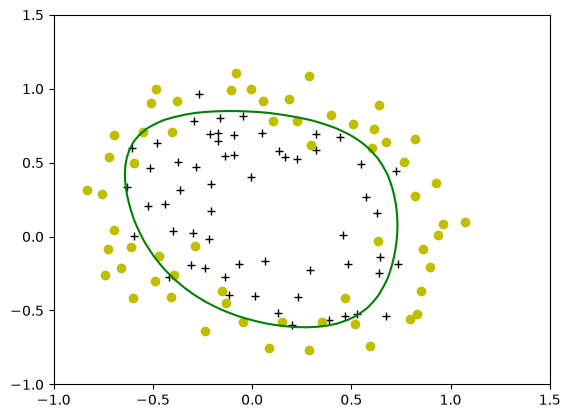

In [49]:
plot_decision_boundary(w, b, X_mapped, y_train)

<a name="3.8"></a>
### 3.8 评估正则化逻辑回归模型

你将使用上面实现的 `predict` 函数，计算正则化逻辑回归模型在训练集上的准确率

In [50]:
#Compute accuracy on the training set
p = predict(X_mapped, w, b)

print('Train Accuracy: %f'%(np.mean(p == y_train) * 100))

Train Accuracy: 82.203390


**预期输出**：
<table>
  <tr>
    <td> <b>训练准确率：</b>~ 80%</td> </tr>
</table>